In [1]:
from google.colab import files
import numpy as np, os

print("Select preds_mm.npz (and preds_mdn.npz if you have it)")
uploaded = files.upload()   # pick the .npz file(s) from your computer
print("\nUploaded:", list(uploaded.keys()))

Select preds_mm.npz (and preds_mdn.npz if you have it)


Saving preds_mm.npz to preds_mm.npz

Uploaded: ['preds_mm.npz']


In [2]:
from scipy import stats
import numpy as np

def coverage(mu, sigma, z, level):
    """Fraction of galaxies whose true z falls in the model's stated central interval.
       If honest, coverage at 0.68 should be ~0.68, at 0.95 ~0.95."""
    k = stats.norm.ppf(0.5 + level/2)          # 0.68 -> 1.0, 0.95 -> 1.96
    inside = np.abs(z - mu) <= k * sigma
    return inside.mean()

def pit_values(mu, sigma, z):
    """PIT = the model's predicted CDF evaluated at the true z.
       If honest, these are uniform on [0,1]. U-shape=overconfident, hump=underconfident."""
    return stats.norm.cdf((z - mu) / sigma)

def pit_uniformity(pit):
    """How far the PIT values are from uniform (0 = perfectly calibrated). Lower is better."""
    return stats.kstest(pit, "uniform").statistic

def crps_gaussian(mu, sigma, z):
    """One number rewarding sharp AND honest predictions (lower is better)."""
    w = (z - mu) / sigma
    return np.mean(sigma * (w*(2*stats.norm.cdf(w)-1) + 2*stats.norm.pdf(w) - 1/np.sqrt(np.pi)))

def calib_report(mu, sigma, z, label):
    print(f"\n--- {label} (n={len(z)}) ---")
    for lv in (0.68, 0.95):
        c = coverage(mu, sigma, z, lv)
        verdict = "overconfident" if c < lv-0.03 else "underconfident" if c > lv+0.03 else "well-calibrated"
        print(f"  {int(lv*100)}% interval -> actual coverage {c:.3f}   ({verdict})")
    pit = pit_values(mu, sigma, z)
    print(f"  PIT non-uniformity : {pit_uniformity(pit):.3f}  (0 = perfect)")
    print(f"  CRPS               : {crps_gaussian(mu, sigma, z):.4f}  (lower = better)")
    return pit

In [3]:
def load(fname):
    d = np.load(fname)
    out = {}
    for split in ("bright", "faint"):
        if f"{split}_mu" in d:
            out[split] = (d[f"{split}_mu"], d[f"{split}_sigma"], d[f"{split}_z"])
    return out

models = {}
for fname, name in [("preds_mm.npz", "Multimodal"), ("preds_mdn.npz", "MDN")]:
    if os.path.exists(fname):
        models[name] = load(fname)

pit_store = {}
for name, splits in models.items():
    print("="*60); print(f"MODEL: {name}")
    for split, (mu, sigma, z) in splits.items():
        pit_store[(name, split)] = calib_report(mu, sigma, z, f"{name} — {split}")

MODEL: Multimodal

--- Multimodal — bright (n=15342) ---
  68% interval -> actual coverage 0.946   (underconfident)
  95% interval -> actual coverage 0.986   (underconfident)
  PIT non-uniformity : 0.202  (0 = perfect)
  CRPS               : 0.0288  (lower = better)

--- Multimodal — faint (n=18000) ---
  68% interval -> actual coverage 0.729   (underconfident)
  95% interval -> actual coverage 0.892   (overconfident)
  PIT non-uniformity : 0.064  (0 = perfect)
  CRPS               : 0.1680  (lower = better)


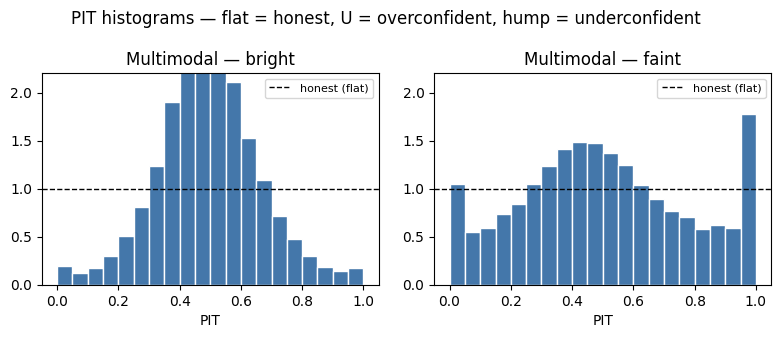

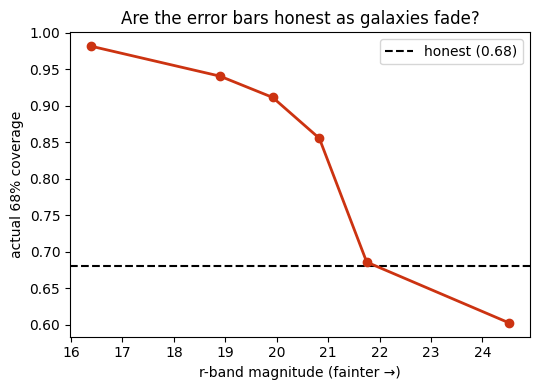

In [4]:
import matplotlib.pyplot as plt

n = len(pit_store)
fig, axes = plt.subplots(1, n, figsize=(4*n, 3.4), squeeze=False)
for ax, ((name, split), pit) in zip(axes[0], pit_store.items()):
    ax.hist(pit, bins=20, range=(0,1), density=True, color="#4477aa", edgecolor="white")
    ax.axhline(1.0, ls="--", c="k", lw=1, label="honest (flat)")
    ax.set(title=f"{name} — {split}", xlabel="PIT", ylim=(0, 2.2))
    ax.legend(fontsize=8)
plt.suptitle("PIT histograms — flat = honest, U = overconfident, hump = underconfident")
plt.tight_layout(); plt.savefig("pit_histograms.png", dpi=130); plt.show()

# coverage-vs-brightness for the multimodal model (needs the saved r-mag)
d = np.load("preds_mm.npz")
if "faint_mag" in d:
    mu = np.concatenate([d["bright_mu"], d["faint_mu"]])
    sg = np.concatenate([d["bright_sigma"], d["faint_sigma"]])
    z  = np.concatenate([d["bright_z"], d["faint_z"]])
    mg = np.concatenate([d["bright_mag"], d["faint_mag"]])
    edges = np.quantile(mg, np.linspace(0,1,7)); cen=[]; cov=[]
    for lo,hi in zip(edges[:-1],edges[1:]):
        m=(mg>=lo)&(mg<hi)
        if m.sum()<50: continue
        cen.append((lo+hi)/2); cov.append(coverage(mu[m],sg[m],z[m],0.68))
    plt.figure(figsize=(5.5,4))
    plt.axhline(0.68, ls="--", c="k", label="honest (0.68)")
    plt.plot(cen, cov, "o-", c="#cc3311", lw=2)
    plt.xlabel("r-band magnitude (fainter →)"); plt.ylabel("actual 68% coverage")
    plt.title("Are the error bars honest as galaxies fade?")
    plt.legend(); plt.tight_layout(); plt.savefig("coverage_vs_brightness.png", dpi=130); plt.show()

In [1]:
import numpy as np
from scipy import stats

HAVE_PDF = False
try:
    d = np.load("pdf_mm.npz"); centers = d["centers"]; edges = d["edges"]; HAVE_PDF = True
    print("Using TRUE PDF calibration.")
except FileNotFoundError:
    d = np.load("preds_mm.npz"); print("pdf_mm.npz not found -> Gaussian-summary fallback.")

def pit_from_pdf(pdf, z, centers):
    """PIT = cumulative predicted probability up to the true redshift's bin."""
    cdf = np.cumsum(pdf, axis=1)
    bin_of_z = np.clip(np.searchsorted(centers, z), 0, pdf.shape[1]-1)
    return cdf[np.arange(len(z)), bin_of_z]

def coverage_from_pdf(pdf, z, centers, level):
    """Smallest central-probability interval holding `level` mass; is true z inside it?
       Central = symmetric around the median of each galaxy's PDF."""
    cdf = np.cumsum(pdf, axis=1)
    lo_q, hi_q = (1-level)/2, 1-(1-level)/2
    lo_bin = np.clip(np.searchsorted(cdf.T, lo_q*np.ones(1), side="left"), 0, len(centers)-1)  # placeholder
    # vectorized per-row interval edges
    lo_edge = centers[[np.searchsorted(c, lo_q) for c in cdf]]
    hi_edge = centers[[min(np.searchsorted(c, hi_q), len(centers)-1) for c in cdf]]
    return np.mean((z >= lo_edge) & (z <= hi_edge))

# Gaussian-summary versions (fallback / cross-check)
def pit_gauss(mu, sigma, z): return stats.norm.cdf((z-mu)/sigma)
def cov_gauss(mu, sigma, z, level):
    k = stats.norm.ppf(0.5+level/2); return np.mean(np.abs(z-mu) <= k*sigma)

Using TRUE PDF calibration.


In [3]:
def coverage_from_pdf(pdf, z, centers, level):
    """Per-galaxy central interval holding `level` probability mass; is true z inside it?
       Central = symmetric in probability around each galaxy's own median."""
    cdf = np.cumsum(pdf, axis=1)                      # (N, B)
    lo_q, hi_q = (1 - level) / 2, 1 - (1 - level) / 2
    N = pdf.shape[0]
    lo_edge = np.empty(N, np.float32)
    hi_edge = np.empty(N, np.float32)
    last = len(centers) - 1
    for i in range(N):                               # per-row 1-D searchsorted (safe, ~fast enough for 33k)
        lo_edge[i] = centers[min(np.searchsorted(cdf[i], lo_q), last)]
        hi_edge[i] = centers[min(np.searchsorted(cdf[i], hi_q), last)]
    return float(np.mean((z >= lo_edge) & (z <= hi_edge)))

def pit_from_pdf(pdf, z, centers):
    """PIT = cumulative predicted probability up to the true redshift's bin."""
    cdf = np.cumsum(pdf, axis=1)
    bin_of_z = np.clip(np.searchsorted(centers, z), 0, pdf.shape[1] - 1)
    return cdf[np.arange(len(z)), bin_of_z]

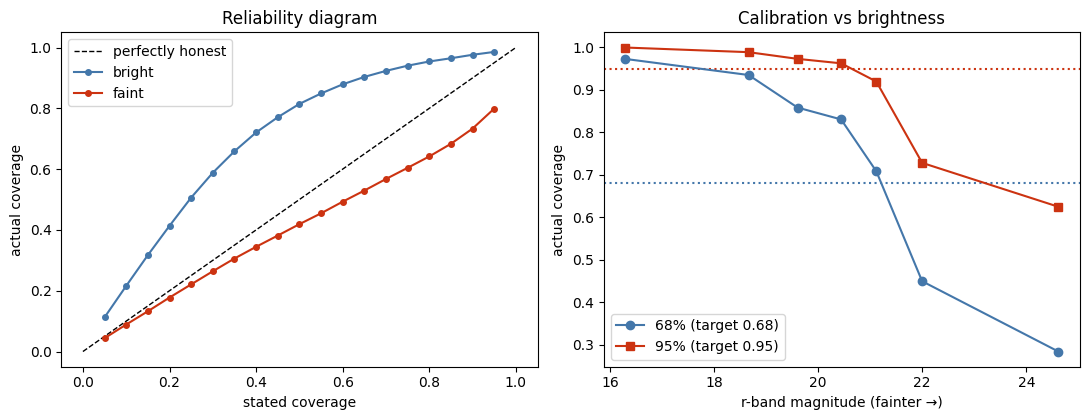

In [4]:
import matplotlib.pyplot as plt

def coverage_curve(split, levels):
    if HAVE_PDF:
        pdf, z = d[f"{split}_pdf"], d[f"{split}_z"]
        return [coverage_from_pdf(pdf, z, centers, lv) for lv in levels]
    mu, sigma, z = d[f"{split}_mu"], d[f"{split}_sigma"], d[f"{split}_z"]
    return [cov_gauss(mu, sigma, z, lv) for lv in levels]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))

# (2) Reliability diagram: nominal vs actual coverage
levels = np.linspace(0.05, 0.95, 19)
ax[0].plot([0,1],[0,1], "k--", lw=1, label="perfectly honest")
for split, c in [("bright","#4477aa"), ("faint","#cc3311")]:
    ax[0].plot(levels, coverage_curve(split, levels), "o-", c=c, ms=4, label=split)
ax[0].set(xlabel="stated coverage", ylabel="actual coverage", title="Reliability diagram")
ax[0].legend()

# (4) Coverage vs brightness (68% and 95%)
mag = np.concatenate([d["bright_mag"], d["faint_mag"]])
if HAVE_PDF:
    pdf = np.concatenate([d["bright_pdf"], d["faint_pdf"]]); z = np.concatenate([d["bright_z"], d["faint_z"]])
    cov68 = lambda m: coverage_from_pdf(pdf[m], z[m], centers, 0.68)
    cov95 = lambda m: coverage_from_pdf(pdf[m], z[m], centers, 0.95)
else:
    mu=np.concatenate([d["bright_mu"],d["faint_mu"]]); sg=np.concatenate([d["bright_sigma"],d["faint_sigma"]])
    z=np.concatenate([d["bright_z"],d["faint_z"]])
    cov68 = lambda m: cov_gauss(mu[m],sg[m],z[m],0.68); cov95 = lambda m: cov_gauss(mu[m],sg[m],z[m],0.95)

qedges = np.quantile(mag, np.linspace(0,1,8)); cen=[]; c68=[]; c95=[]
for lo,hi in zip(qedges[:-1], qedges[1:]):
    m = (mag>=lo)&(mag<hi)
    if m.sum()<50: continue
    cen.append((lo+hi)/2); c68.append(cov68(m)); c95.append(cov95(m))
ax[1].axhline(0.68, ls=":", c="#4477aa"); ax[1].axhline(0.95, ls=":", c="#cc3311")
ax[1].plot(cen, c68, "o-", c="#4477aa", label="68% (target 0.68)")
ax[1].plot(cen, c95, "s-", c="#cc3311", label="95% (target 0.95)")
ax[1].set(xlabel="r-band magnitude (fainter →)", ylabel="actual coverage",
          title="Calibration vs brightness"); ax[1].legend()
plt.tight_layout(); plt.savefig("calibration_figures.png", dpi=130); plt.show()

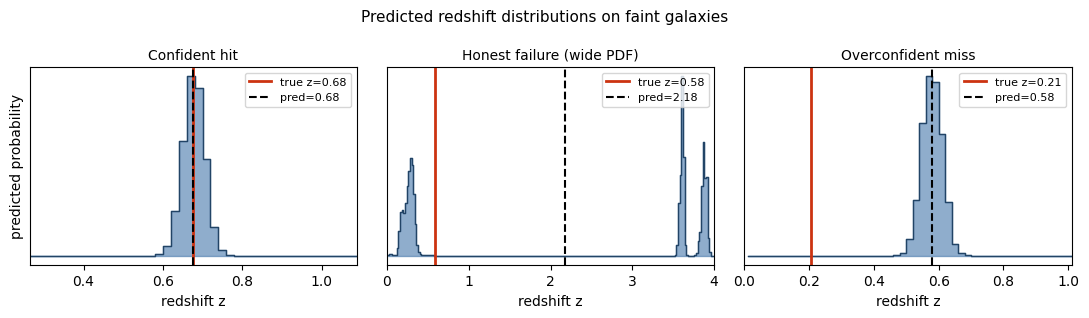

Confident hit                true=0.675  pred=0.677  sigma=0.028  |dz|=0.001
Honest failure (wide PDF)    true=0.582  pred=2.179  sigma=1.731  |dz|=1.010
Overconfident miss           true=0.206  pred=0.579  sigma=0.033  |dz|=0.309


In [5]:
import numpy as np, matplotlib.pyplot as plt

d = np.load("pdf_mm.npz")
centers = d["centers"]

# use the FAINT set — that's where the interesting behavior lives
pdf = d["faint_pdf"]; z = d["faint_z"]
mu  = (pdf * centers).sum(1)                                   # point estimate
sig = np.sqrt((pdf * centers**2).sum(1) - mu**2)              # predictive std
dz  = (mu - z) / (1 + z)

# --- pick three representative galaxies ---
# 1) confident hit: small error AND narrow PDF
hit   = np.argmin(np.abs(dz) + sig)
# 2) honest miss: large error BUT wide PDF (model knows it's unsure)
honest = np.argmax(np.where(np.abs(dz) > 0.15, sig, -1))
# 3) catastrophic overconfident miss: large error AND narrow PDF
conf_miss = np.argmax(np.where(np.abs(dz) > 0.15, 1.0/(sig+1e-3), -1))

cases = [("Confident hit", hit),
         ("Honest failure (wide PDF)", honest),
         ("Overconfident miss", conf_miss)]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, (title, i) in zip(axes, cases):
    ax.fill_between(centers, pdf[i], color="#4477aa", alpha=0.6, step="mid")
    ax.plot(centers, pdf[i], color="#224466", lw=1, drawstyle="steps-mid")
    ax.axvline(z[i],  color="#cc3311", lw=2, label=f"true z={z[i]:.2f}")
    ax.axvline(mu[i], color="black", ls="--", lw=1.5, label=f"pred={mu[i]:.2f}")
    hi = min(4, max(z[i], mu[i]) + 4*sig[i] + 0.3)
    lo = max(0, min(z[i], mu[i]) - 4*sig[i] - 0.3)
    ax.set_xlim(lo, hi)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("redshift z"); ax.set_yticks([])
    ax.legend(fontsize=8, loc="upper right")
axes[0].set_ylabel("predicted probability")
plt.suptitle("Predicted redshift distributions on faint galaxies", fontsize=11)
plt.tight_layout()
plt.savefig("qualitative_pdfs.png", dpi=140, bbox_inches="tight")
plt.show()

# print what was chosen, so you can describe them in the caption
for title, i in cases:
    print(f"{title:28} true={z[i]:.3f}  pred={mu[i]:.3f}  sigma={sig[i]:.3f}  |dz|={abs(dz[i]):.3f}")